<a href="https://colab.research.google.com/github/Sapnajolly/Artificial-Intelligence/blob/main/Day_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
corpus = [
    "The dog ran happily across the park chasing a ball.",
    "My puppy loves to play fetch in the backyard every morning.",
    "The cat curled up on the warm windowsill and fell asleep.",
    "Our kitten is very playful and enjoys chasing string toys.",
    "The airplane took off smoothly and climbed to cruising altitude.",
    "Passengers boarded the flight before the plane departed the gate.",
    "The pilot announced a delay due to bad weather at the airport.",
    "She chopped fresh vegetables and added them to the simmering soup.",
    "The recipe calls for two cups of flour and a pinch of salt.",
    "He grilled the chicken with garlic and herbs for dinner tonight.",
]
topics = ["pets"]*4 + ["aviation"]*3 + ["cooking"]*3
for i, (s, t) in enumerate(zip(corpus, topics)):
    print(f"[{i}] ({t}) {s}")

[0] (pets) The dog ran happily across the park chasing a ball.
[1] (pets) My puppy loves to play fetch in the backyard every morning.
[2] (pets) The cat curled up on the warm windowsill and fell asleep.
[3] (pets) Our kitten is very playful and enjoys chasing string toys.
[4] (aviation) The airplane took off smoothly and climbed to cruising altitude.
[5] (aviation) Passengers boarded the flight before the plane departed the gate.
[6] (aviation) The pilot announced a delay due to bad weather at the airport.
[7] (cooking) She chopped fresh vegetables and added them to the simmering soup.
[8] (cooking) The recipe calls for two cups of flour and a pinch of salt.
[9] (cooking) He grilled the chicken with garlic and herbs for dinner tonight.


In [5]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(corpus)
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(vectorizer.get_feature_names_out()[:15])

TF-IDF matrix shape: (10, 82)
['across' 'added' 'airplane' 'airport' 'altitude' 'and' 'announced'
 'asleep' 'at' 'backyard' 'bad' 'ball' 'before' 'boarded' 'calls']


In [6]:
similarity_matrix = cosine_similarity(tfidf_matrix)
similarity_matrix = np.array(similarity_matrix)
np.set_printoptions(precision=2, suppress=True)
print(similarity_matrix)

[[1.   0.04 0.08 0.09 0.04 0.12 0.08 0.04 0.03 0.04]
 [0.04 1.   0.04 0.   0.07 0.05 0.08 0.07 0.02 0.02]
 [0.08 0.04 1.   0.03 0.07 0.11 0.07 0.07 0.06 0.07]
 [0.09 0.   0.03 1.   0.03 0.   0.   0.03 0.03 0.03]
 [0.04 0.07 0.07 0.03 1.   0.06 0.09 0.11 0.05 0.05]
 [0.12 0.05 0.11 0.   0.06 1.   0.11 0.06 0.05 0.06]
 [0.08 0.08 0.07 0.   0.09 0.11 1.   0.09 0.03 0.04]
 [0.04 0.07 0.07 0.03 0.11 0.06 0.09 1.   0.04 0.05]
 [0.03 0.02 0.06 0.03 0.05 0.05 0.03 0.04 1.   0.11]
 [0.04 0.02 0.07 0.03 0.05 0.06 0.04 0.05 0.11 1.  ]]


In [7]:
def find_similar(query, corpus, top_k=3, vectorizer=vectorizer):
    corpus_vectors = vectorizer.transform(corpus)
    query_vector = vectorizer.transform([query])
    scores = cosine_similarity(query_vector, corpus_vectors)[0]
    ranked_indices = np.argsort(scores)[::-1][:top_k]
    return [(corpus[i], float(scores[i])) for i in ranked_indices]

query = "A small puppy is playing in the yard."
for sent, score in find_similar(query, corpus, top_k=3):
    print(f"{score:.4f}  ->  {sent}")

0.3926  ->  My puppy loves to play fetch in the backyard every morning.
0.1873  ->  Our kitten is very playful and enjoys chasing string toys.
0.0950  ->  Passengers boarded the flight before the plane departed the gate.


In [8]:
test_pairs = [("dog", "puppy"), ("dog", "airplane"), ("cat", "kitten"),
              ("flight", "airport"), ("recipe", "vegetables"), ("dog", "soup")]
for a, b in test_pairs:
    va, vb = vectorizer.transform([a]), vectorizer.transform([b])
    score = cosine_similarity(va, vb)[0][0]
    print(f"{a:<12}{b:<12}{score:.4f}")

dog         puppy       0.0000
dog         airplane    0.0000
cat         kitten      0.0000
flight      airport     0.0000
recipe      vegetables  0.0000
dog         soup        0.0000


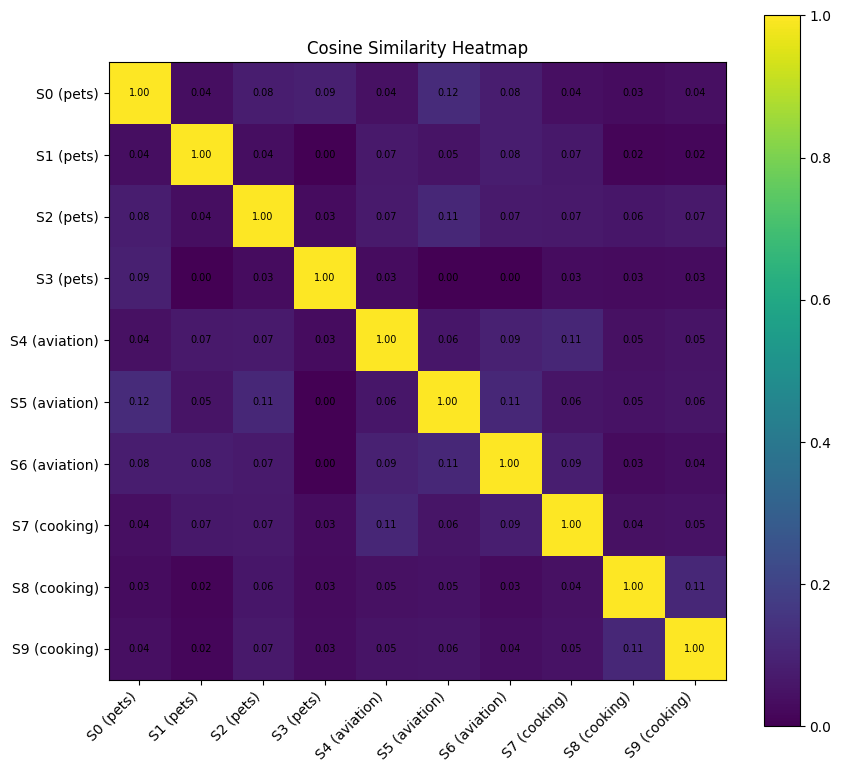

In [9]:
labels = [f"S{i} ({t})" for i, t in enumerate(topics)]
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(similarity_matrix, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{similarity_matrix[i,j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Cosine Similarity Heatmap")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()